In [1]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 29.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 10.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.3 MB/s eta 0:00:00:00:01m00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.8 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.9.41
    Uninstalling nvidia-nvjitlink-cu12-12.9.41:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.9.41
  Attempting uninstall: nvidia-curand-cu12
    Found existing 

Using device: cuda
Model parameters: 6,675,202

Color Mapping for Visualization:
Corrosion: Yellow [255, 255, 0]
Spalling: Red [255, 0, 0]
--------------------------------------------------


Epoch 1/5 [Train]:   0%|          | 0/177 [00:00<?, ?it/s]

Epoch 1/5 [Val]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 1/5:
  Train - Loss: 1.3559
    Corrosion - Dice: 0.261, F1: 0.261, Acc: 0.586
    Spalling  - Dice: 0.591, F1: 0.591, Acc: 0.688
  Val   - Loss: 1.3995
    Corrosion - Dice: 0.365, F1: 0.365, Acc: 0.840
    Spalling  - Dice: 0.630, F1: 0.630, Acc: 0.867
  LR: 0.000090
--------------------------------------------------------------------------------


Epoch 2/5 [Train]:   0%|          | 0/177 [00:00<?, ?it/s]

...

Epoch 4/5 [Val]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 4/5:
  Train - Loss: 1.1761
    Corrosion - Dice: 0.350, F1: 0.350, Acc: 0.794
    Spalling  - Dice: 0.702, F1: 0.702, Acc: 0.759
  Val   - Loss: 1.4108
    Corrosion - Dice: 0.438, F1: 0.438, Acc: 0.888
    Spalling  - Dice: 0.548, F1: 0.548, Acc: 0.850
  LR: 0.000010
--------------------------------------------------------------------------------


Epoch 5/5 [Train]:   0%|          | 0/177 [00:00<?, ?it/s]

Epoch 5/5 [Val]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 5/5:
  Train - Loss: 1.1612
    Corrosion - Dice: 0.363, F1: 0.363, Acc: 0.809
    Spalling  - Dice: 0.708, F1: 0.708, Acc: 0.765
  Val   - Loss: 1.4268
    Corrosion - Dice: 0.400, F1: 0.400, Acc: 0.867
    Spalling  - Dice: 0.508, F1: 0.508, Acc: 0.842
  LR: 0.000000
--------------------------------------------------------------------------------


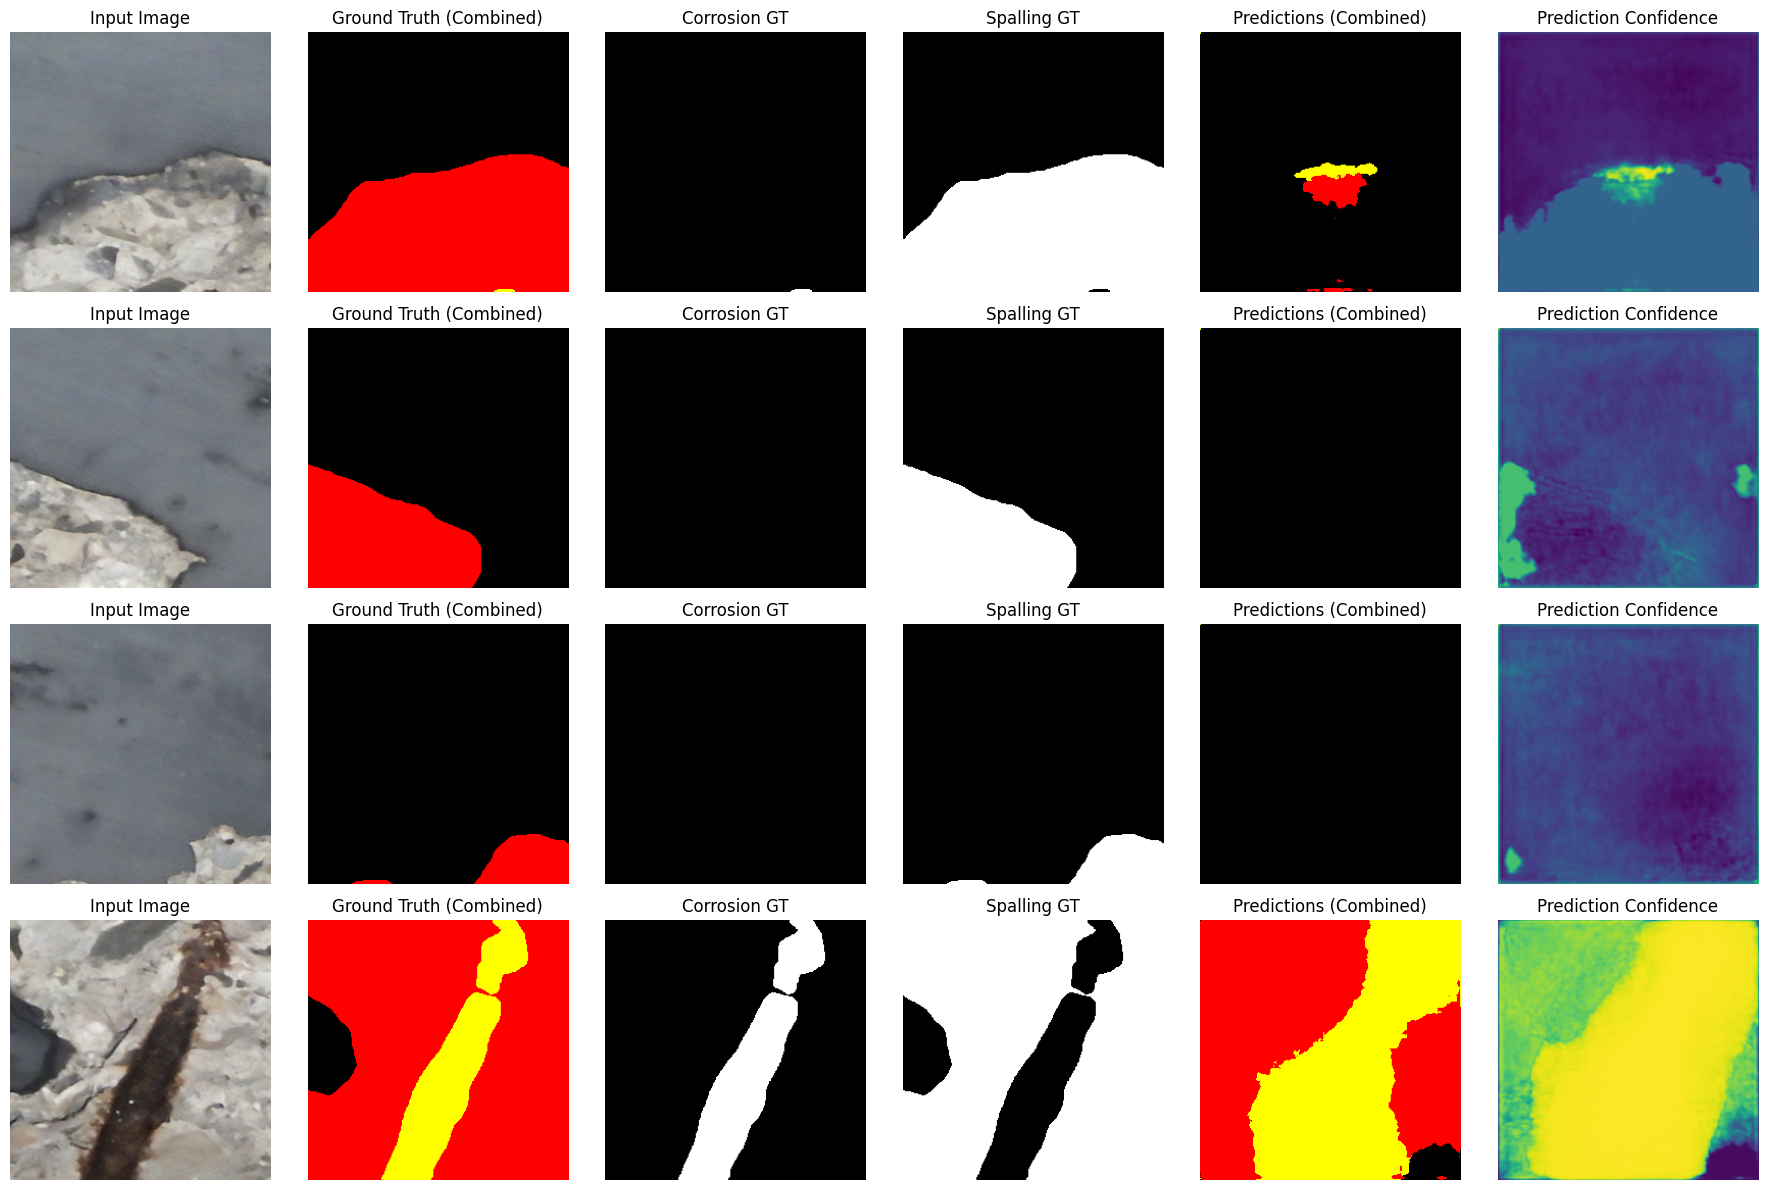

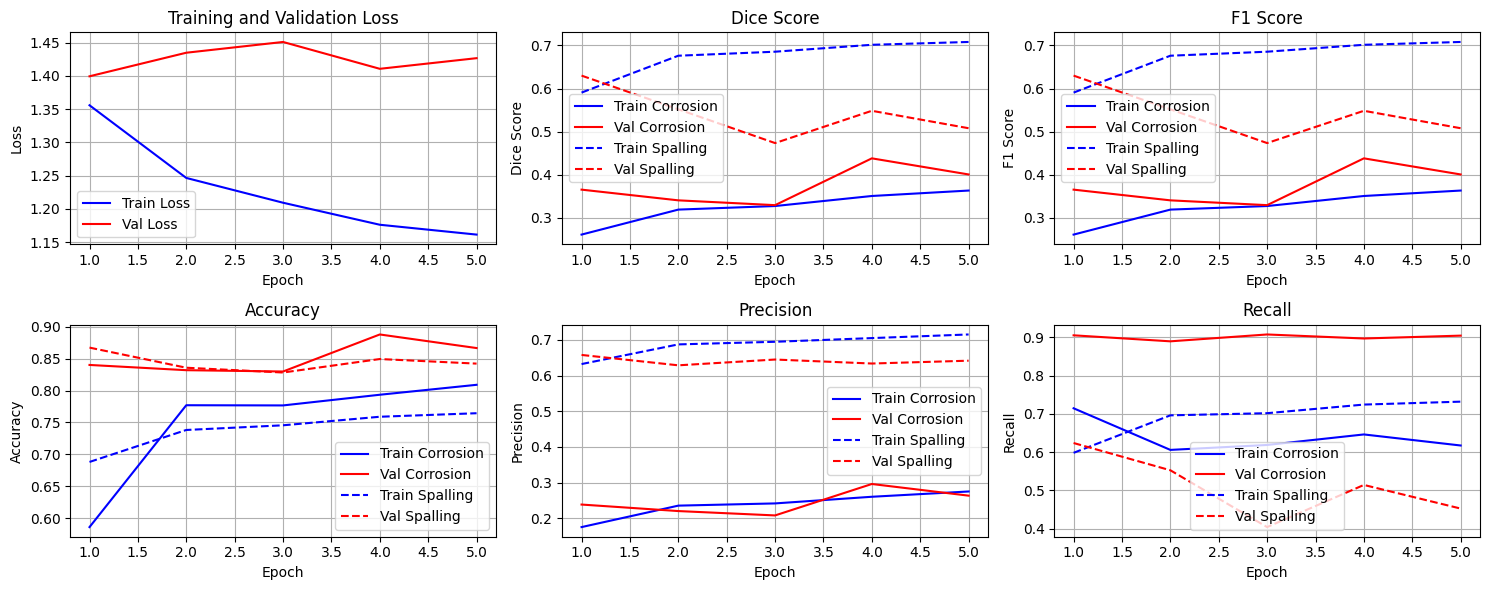

In [9]:
# Enhanced Multitask Concrete Defect Segmentation with Dice Loss and Comprehensive Metrics
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import segmentation_models_pytorch as smp
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')

# Configuration
CLASS_COLOR_MAP = {
    "corrosion": [255, 255, 0],
    "spalling": [255, 0, 0]
}
CLASS_NAMES = list(CLASS_COLOR_MAP.keys())

def rgb_to_multichannel_mask(mask, class_color_map=CLASS_COLOR_MAP):
    """Convert RGB mask to multichannel binary mask"""
    h, w, _ = mask.shape
    mask_out = np.zeros((len(class_color_map), h, w), dtype=np.uint8)
    for i, (cls, color) in enumerate(class_color_map.items()):
        class_mask = np.all(mask == color, axis=-1)
        mask_out[i, :, :] = class_mask.astype(np.uint8)
    return mask_out

def multichannel_to_rgb_mask(mask, class_color_map=CLASS_COLOR_MAP):
    """Convert multichannel binary mask to RGB visualization"""
    h, w = mask.shape[-2:]
    rgb_mask = np.zeros((h, w, 3), dtype=np.uint8)
    
    for i, (cls, color) in enumerate(class_color_map.items()):
        class_mask = mask[i] > 0.5
        rgb_mask[class_mask] = color
    
    return rgb_mask

class ConcreteDefectDataset(Dataset):
    def __init__(self, root_dir, transform=None, mask_transform=None):
        self.root_dir = root_dir
        self.image_files = sorted([f for f in os.listdir(root_dir) if f.endswith('.png') and '_lab' not in f])
        self.transform = transform
        self.mask_transform = mask_transform
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.root_dir, img_name)
        mask_path = os.path.join(self.root_dir, img_name.replace('.png', '_lab.png'))
        
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        mask_np = np.array(mask)
        mask_mc = rgb_to_multichannel_mask(mask_np)
        mask_tensor = torch.from_numpy(mask_mc).float()
        
        if self.mask_transform:
            mask_tensor = self.mask_transform(mask_tensor)
        
        return image, mask_tensor

# Enhanced data augmentation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
])

# Multitask UNet Model
class TaskSpecificHead(nn.Module):
    def __init__(self, in_channels, num_classes=1):
        super(TaskSpecificHead, self).__init__()
        self.head = nn.Sequential(
            nn.Conv2d(in_channels, in_channels//2, 3, padding=1),
            nn.BatchNorm2d(in_channels//2),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),
            nn.Conv2d(in_channels//2, num_classes, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.head(x)

class MultitaskUNet(nn.Module):
    def __init__(self, encoder_name='mobilenet_v2', num_classes_per_task=1):
        super(MultitaskUNet, self).__init__()
        
        # Shared encoder and decoder
        self.shared_model = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights='imagenet',
            in_channels=3,
            classes=64,  # Output features for task-specific heads
            activation=None
        )
        
        # Task-specific heads
        self.corrosion_head = TaskSpecificHead(64, num_classes_per_task)
        self.spalling_head = TaskSpecificHead(64, num_classes_per_task)
    
    def forward(self, x):
        # Shared feature extraction
        shared_features = self.shared_model(x)
        
        # Task-specific outputs
        corrosion_output = self.corrosion_head(shared_features)
        spalling_output = self.spalling_head(shared_features)
        
        return {
            'corrosion': corrosion_output,
            'spalling': spalling_output
        }

# Dice Loss Function
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth
    
    def forward(self, pred, target):
        pred = pred.contiguous().view(-1)
        target = target.contiguous().view(-1)
        
        intersection = (pred * target).sum()
        dice_score = (2. * intersection + self.smooth) / (pred.sum() + target.sum() + self.smooth)
        
        return 1 - dice_score

class MultitaskDiceLoss(nn.Module):
    def __init__(self, task_weights=None):
        super(MultitaskDiceLoss, self).__init__()
        self.task_weights = task_weights or {'corrosion': 1.0, 'spalling': 1.0}
        self.dice_loss = DiceLoss()
    
    def forward(self, predictions, targets):
        total_loss = 0
        losses = {}
        
        for i, task in enumerate(['corrosion', 'spalling']):
            pred = predictions[task]
            target = targets[:, [i]]
            
            task_loss = self.dice_loss(pred, target)
            losses[f'{task}_loss'] = task_loss
            total_loss += self.task_weights[task] * task_loss
        
        losses['total_loss'] = total_loss
        return losses

# Comprehensive metrics calculation
def calculate_comprehensive_metrics(predictions, targets, threshold=0.5):
    """Calculate accuracy, F1, Dice, precision, and recall for each task"""
    metrics = {}
    
    for i, task in enumerate(['corrosion', 'spalling']):
        pred = predictions[task].detach().cpu().numpy()
        target = targets[:, [i]].detach().cpu().numpy()
        
        pred_binary = (pred > threshold).astype(np.uint8)
        target_binary = target.astype(np.uint8)
        
        # Flatten for sklearn metrics
        pred_flat = pred_binary.flatten()
        target_flat = target_binary.flatten()
        
        # Calculate metrics
        accuracy = accuracy_score(target_flat, pred_flat)
        f1 = f1_score(target_flat, pred_flat, average='binary', zero_division=0)
        precision = precision_score(target_flat, pred_flat, average='binary', zero_division=0)
        recall = recall_score(target_flat, pred_flat, average='binary', zero_division=0)
        
        # Dice score (manual calculation)
        intersection = np.sum(pred_binary * target_binary)
        dice = (2 * intersection) / (np.sum(pred_binary) + np.sum(target_binary) + 1e-8)
        
        metrics[f'{task}_accuracy'] = accuracy
        metrics[f'{task}_f1'] = f1
        metrics[f'{task}_dice'] = dice
        metrics[f'{task}_precision'] = precision
        metrics[f'{task}_recall'] = recall
    
    return metrics

# Enhanced training function
def train_model(model, train_loader, val_loader, epochs=3, lr=1e-2, device='cuda'):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = MultitaskDiceLoss(task_weights={'corrosion': 1.0, 'spalling': 1.2})
    
    best_val_loss = float('inf')
    train_history = []
    val_history = []
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        train_metrics = {
            'corrosion_accuracy': 0, 'corrosion_f1': 0, 'corrosion_dice': 0, 'corrosion_precision': 0, 'corrosion_recall': 0,
            'spalling_accuracy': 0, 'spalling_f1': 0, 'spalling_dice': 0, 'spalling_precision': 0, 'spalling_recall': 0
        }
        train_batches = 0
        
        train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]')
        for images, masks in train_bar:
            images, masks = images.to(device), masks.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            
            loss_dict = criterion(outputs, masks)
            loss = loss_dict['total_loss']
            
            loss.backward()
            optimizer.step()
            
            # Calculate metrics
            batch_metrics = calculate_comprehensive_metrics(outputs, masks)
            for key in train_metrics:
                train_metrics[key] += batch_metrics[key]
            
            train_loss += loss.item()
            train_batches += 1
            
            train_bar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Corr_Dice': f'{batch_metrics["corrosion_dice"]:.3f}',
                'Spal_Dice': f'{batch_metrics["spalling_dice"]:.3f}'
            })
        
        # Validation
        model.eval()
        val_loss = 0
        val_metrics = {
            'corrosion_accuracy': 0, 'corrosion_f1': 0, 'corrosion_dice': 0, 'corrosion_precision': 0, 'corrosion_recall': 0,
            'spalling_accuracy': 0, 'spalling_f1': 0, 'spalling_dice': 0, 'spalling_precision': 0, 'spalling_recall': 0
        }
        val_batches = 0
        
        with torch.no_grad():
            val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs} [Val]')
            for images, masks in val_bar:
                images, masks = images.to(device), masks.to(device)
                
                outputs = model(images)
                loss_dict = criterion(outputs, masks)
                
                batch_metrics = calculate_comprehensive_metrics(outputs, masks)
                for key in val_metrics:
                    val_metrics[key] += batch_metrics[key]
                
                val_loss += loss_dict['total_loss'].item()
                val_batches += 1
                
                val_bar.set_postfix({
                    'Loss': f'{loss_dict["total_loss"].item():.4f}',
                    'Corr_Dice': f'{batch_metrics["corrosion_dice"]:.3f}',
                    'Spal_Dice': f'{batch_metrics["spalling_dice"]:.3f}'
                })
        
        # Calculate averages
        avg_train_loss = train_loss / train_batches
        avg_val_loss = val_loss / val_batches
        
        for key in train_metrics:
            train_metrics[key] /= train_batches
            val_metrics[key] /= val_batches
        
        scheduler.step()
        
        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': avg_val_loss,
                'val_metrics': val_metrics
            }, 'best_multitask_model.pth')
        
        # Store history
        train_history.append({'loss': avg_train_loss, **train_metrics})
        val_history.append({'loss': avg_val_loss, **val_metrics})
        
        # Print comprehensive metrics
        print(f'Epoch {epoch+1}/{epochs}:')
        print(f'  Train - Loss: {avg_train_loss:.4f}')
        print(f'    Corrosion - Dice: {train_metrics["corrosion_dice"]:.3f}, F1: {train_metrics["corrosion_f1"]:.3f}, Acc: {train_metrics["corrosion_accuracy"]:.3f}')
        print(f'    Spalling  - Dice: {train_metrics["spalling_dice"]:.3f}, F1: {train_metrics["spalling_f1"]:.3f}, Acc: {train_metrics["spalling_accuracy"]:.3f}')
        print(f'  Val   - Loss: {avg_val_loss:.4f}')
        print(f'    Corrosion - Dice: {val_metrics["corrosion_dice"]:.3f}, F1: {val_metrics["corrosion_f1"]:.3f}, Acc: {val_metrics["corrosion_accuracy"]:.3f}')
        print(f'    Spalling  - Dice: {val_metrics["spalling_dice"]:.3f}, F1: {val_metrics["spalling_f1"]:.3f}, Acc: {val_metrics["spalling_accuracy"]:.3f}')
        print(f'  LR: {scheduler.get_last_lr()[0]:.6f}')
        print('-' * 80)
    
    return train_history, val_history

# Enhanced visualization function with color mapping
def visualize_predictions(model, dataset, device='cuda', num_samples=4):
    model.eval()
    fig, axes = plt.subplots(num_samples, 6, figsize=(18, 3*num_samples))
    
    with torch.no_grad():
        for i in range(num_samples):
            image, mask = dataset[i]
            image_batch = image.unsqueeze(0).to(device)
            
            outputs = model(image_batch)
            
            # Convert to numpy
            img_np = image.permute(1, 2, 0).cpu().numpy()
            corr_true = mask[0].cpu().numpy()
            spal_true = mask[1].cpu().numpy()
            corr_pred = outputs['corrosion'][0, 0].cpu().numpy()
            spal_pred = outputs['spalling'][0, 0].cpu().numpy()
            
            # Create combined prediction mask with color mapping
            combined_pred = np.zeros((2, *corr_pred.shape))
            combined_pred[0] = corr_pred > 0.5  # Corrosion
            combined_pred[1] = spal_pred > 0.5  # Spalling
            
            # Convert to RGB with color mapping
            pred_rgb = multichannel_to_rgb_mask(combined_pred)
            
            # Ground truth RGB
            gt_rgb = multichannel_to_rgb_mask(mask.cpu().numpy())
            
            # Plot
            axes[i, 0].imshow(img_np)
            axes[i, 0].set_title('Input Image')
            axes[i, 0].axis('off')
            
            axes[i, 1].imshow(gt_rgb)
            axes[i, 1].set_title('Ground Truth (Combined)')
            axes[i, 1].axis('off')
            
            axes[i, 2].imshow(corr_true, cmap='gray')
            axes[i, 2].set_title('Corrosion GT')
            axes[i, 2].axis('off')
            
            axes[i, 3].imshow(spal_true, cmap='gray')
            axes[i, 3].set_title('Spalling GT')
            axes[i, 3].axis('off')
            
            axes[i, 4].imshow(pred_rgb)
            axes[i, 4].set_title('Predictions (Combined)')
            axes[i, 4].axis('off')
            
            # Show prediction confidence
            combined_conf = np.maximum(corr_pred, spal_pred)
            axes[i, 5].imshow(combined_conf, cmap='viridis')
            axes[i, 5].set_title('Prediction Confidence')
            axes[i, 5].axis('off')
    
    plt.tight_layout()
    plt.show()

# Enhanced plotting function for comprehensive metrics
def plot_comprehensive_training_history(train_history, val_history):
    epochs = range(1, len(train_history) + 1)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 6))
    
    # Loss
    axes[0, 0].plot(epochs, [h['loss'] for h in train_history], 'b-', label='Train Loss')
    axes[0, 0].plot(epochs, [h['loss'] for h in val_history], 'r-', label='Val Loss')
    axes[0, 0].set_title('Training and Validation Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # Dice Score
    axes[0, 1].plot(epochs, [h['corrosion_dice'] for h in train_history], 'b-', label='Train Corrosion')
    axes[0, 1].plot(epochs, [h['corrosion_dice'] for h in val_history], 'r-', label='Val Corrosion')
    axes[0, 1].plot(epochs, [h['spalling_dice'] for h in train_history], 'b--', label='Train Spalling')
    axes[0, 1].plot(epochs, [h['spalling_dice'] for h in val_history], 'r--', label='Val Spalling')
    axes[0, 1].set_title('Dice Score')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Dice Score')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # F1 Score
    axes[0, 2].plot(epochs, [h['corrosion_f1'] for h in train_history], 'b-', label='Train Corrosion')
    axes[0, 2].plot(epochs, [h['corrosion_f1'] for h in val_history], 'r-', label='Val Corrosion')
    axes[0, 2].plot(epochs, [h['spalling_f1'] for h in train_history], 'b--', label='Train Spalling')
    axes[0, 2].plot(epochs, [h['spalling_f1'] for h in val_history], 'r--', label='Val Spalling')
    axes[0, 2].set_title('F1 Score')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('F1 Score')
    axes[0, 2].legend()
    axes[0, 2].grid(True)
    
    # Accuracy
    axes[1, 0].plot(epochs, [h['corrosion_accuracy'] for h in train_history], 'b-', label='Train Corrosion')
    axes[1, 0].plot(epochs, [h['corrosion_accuracy'] for h in val_history], 'r-', label='Val Corrosion')
    axes[1, 0].plot(epochs, [h['spalling_accuracy'] for h in train_history], 'b--', label='Train Spalling')
    axes[1, 0].plot(epochs, [h['spalling_accuracy'] for h in val_history], 'r--', label='Val Spalling')
    axes[1, 0].set_title('Accuracy')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].legend()
    axes[1, 0].grid(True)
    
    # Precision
    axes[1, 1].plot(epochs, [h['corrosion_precision'] for h in train_history], 'b-', label='Train Corrosion')
    axes[1, 1].plot(epochs, [h['corrosion_precision'] for h in val_history], 'r-', label='Val Corrosion')
    axes[1, 1].plot(epochs, [h['spalling_precision'] for h in train_history], 'b--', label='Train Spalling')
    axes[1, 1].plot(epochs, [h['spalling_precision'] for h in val_history], 'r--', label='Val Spalling')
    axes[1, 1].set_title('Precision')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Precision')
    axes[1, 1].legend()
    axes[1, 1].grid(True)
    
    # Recall
    axes[1, 2].plot(epochs, [h['corrosion_recall'] for h in train_history], 'b-', label='Train Corrosion')
    axes[1, 2].plot(epochs, [h['corrosion_recall'] for h in val_history], 'r-', label='Val Corrosion')
    axes[1, 2].plot(epochs, [h['spalling_recall'] for h in train_history], 'b--', label='Train Spalling')
    axes[1, 2].plot(epochs, [h['spalling_recall'] for h in val_history], 'r--', label='Val Spalling')
    axes[1, 2].set_title('Recall')
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].set_ylabel('Recall')
    axes[1, 2].legend()
    axes[1, 2].grid(True)
    
    plt.tight_layout()
    plt.show()

# Main execution
if __name__ == "__main__":
    # Dataset loading
    train_dataset = ConcreteDefectDataset(
        '/kaggle/input/corrosion-and-spalling-concrete-defect-segmentation/spalling_corrosion_patches/train', 
        transform=train_transform
    )
    val_dataset = ConcreteDefectDataset(
        '/kaggle/input/corrosion-and-spalling-concrete-defect-segmentation/spalling_corrosion_patches/val', 
        transform=val_transform
    )
    
    # DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)
    
    # Initialize model
    model = MultitaskUNet(encoder_name='mobilenet_v2', num_classes_per_task=1)
    
    # Check device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    # Display color mapping info
    print("\nColor Mapping for Visualization:")
    print("Corrosion: Yellow [255, 255, 0]")
    print("Spalling: Red [255, 0, 0]")
    print("-" * 50)
    
    # Train the model
    train_history, val_history = train_model(
        model, train_loader, val_loader, 
        epochs=5, lr=1e-4, device=device
    )
    
    # Visualize predictions with color mapping
    visualize_predictions(model, val_dataset, device=device, num_samples=4)
    
    # Plot comprehensive training history
    plot_comprehensive_training_history(train_history, val_history)